Project: Shipment & Logistics Management System
Using MySQL, Python, Pandas, and Data Visualization

In [15]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [16]:
orders = pd.read_excel("global_superstore_2016.xlsx", sheet_name="Orders")
returns = pd.read_excel("global_superstore_2016.xlsx", sheet_name="Returns")
people = pd.read_excel("global_superstore_2016.xlsx", sheet_name="People")

In [17]:
orders_df = orders.copy()
returns_df = returns.copy()
people_df = people.copy()

In [18]:
print("Orders :", orders_df.shape)
print("Returns:", returns_df.shape)
print("people :", people_df.shape)

Orders : (51290, 24)
Returns: (1079, 3)
people : (24, 2)


In [19]:
orders_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [20]:
returns_df.head()

,Returned,Order ID,Region
0,Yes,CA-2012-SA20830140-41210,Central US
1,Yes,IN-2012-PB19210127-41259,Eastern Asia
2,Yes,CA-2012-SC20095140-41174,Central US
3,Yes,IN-2015-JH158207-42140,Oceania
4,Yes,IN-2014-LC168857-41747,Oceania


In [21]:
people_df.head()

,Person,Region
0,Marilène Rousseau,Caribbean
1,Andile Ihejirika,Central Africa
2,Nicodemo Bautista,Central America
3,Cansu Peynirci,Central Asia
4,Lon Bonher,Central US


In [22]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   Postal Code     9994 non-null   float64       
 9   City            51290 non-null  object        
 10  State           51290 non-null  object        
 11  Country         51290 non-null  object        
 12  Region          51290 non-null  object        
 13  Market          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [23]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Returned  1079 non-null   object
 1   Order ID  1079 non-null   object
 2   Region    1079 non-null   object
dtypes: object(3)
memory usage: 25.4+ KB


In [24]:
people_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Person  24 non-null     object
 1   Region  24 non-null     object
dtypes: object(2)
memory usage: 516.0+ bytes


In [27]:
orders_df.columns = (
    orders_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

returns_df.columns = (
    returns_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

people_df.columns = (
    people_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [28]:
orders_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'postal_code', 'city',
       'state', 'country', 'region', 'market', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority'],
      dtype='object')

In [29]:
orders_df.dtypes

row_id                     int64
order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_id               object
customer_name             object
segment                   object
postal_code              float64
city                      object
state                     object
country                   object
region                    object
market                    object
product_id                object
category                  object
sub-category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
dtype: object

In [30]:
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])
orders_df["ship_date"] = pd.to_datetime(orders_df["ship_date"])

In [33]:
orders_df["delivery_days"] = (orders_df["ship_date"] - orders_df["order_date"]).dt.days

In [34]:
orders_df[["order_date", "ship_date", "delivery_days"]].head()

,order_date,ship_date,delivery_days
0,2014-11-11,2014-11-13,2
1,2014-02-05,2014-02-07,2
2,2014-10-17,2014-10-18,1
3,2014-01-28,2014-01-30,2
4,2014-11-05,2014-11-06,1


In [35]:
orders_df.describe()

,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit,shipping_cost,delivery_days
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2014-05-11 21:26:49.155780608,2014-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.478567,3.969370
min,1.00000,2012-01-01 00:00:00,2012-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,1.002000,0.000000
25%,12823.25000,2013-06-19 00:00:00,2013-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000,3.000000
50%,25645.50000,2014-07-08 00:00:00,2014-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000,4.000000
75%,38467.75000,2015-05-22 00:00:00,2015-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000,5.000000
max,51290.00000,2015-12-31 00:00:00,2016-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000,7.000000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.251373,1.729437


In [36]:
orders_df.to_csv("orders_clean.csv", index=False)

returns_df.to_csv("returns_clean.csv", index=False)

people_df.to_csv("people_clean.csv", index=False)

In [101]:
import sqlite3

conn = sqlite3.connect("shipment_logistics.db")
cursor = conn.cursor()

print("New database created.")

New database created.


In [102]:
cursor.execute("""
CREATE TABLE customers (
    customer_id TEXT PRIMARY KEY,
    customer_name TEXT,
    segment TEXT
)
""")

conn.commit()
print("Customers table created successfully!")

Customers table created successfully!


In [118]:
cursor.execute("""
CREATE TABLE products (
    product_id TEXT PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT NOT NULL
);
""")

conn.commit()

print("Products table created successfully!")

Products table created successfully!


In [127]:
cursor.execute("""
CREATE TABLE locations (
    location_id INTEGER PRIMARY KEY AUTOINCREMENT,
    postal_code INTEGER,
    city TEXT,
    state TEXT,
    country TEXT,
    region TEXT,
    market TEXT
);
""")

conn.commit()

print("Locations table created successfully!")

Locations table created successfully!


In [141]:
cursor.execute("""
CREATE TABLE people (
    region TEXT PRIMARY KEY,
    person TEXT
);
""")

conn.commit()

print("People table created successfully!")

People table created successfully!


In [106]:
cursor.execute("""
CREATE TABLE returns (
    order_id TEXT PRIMARY KEY,
    returned TEXT
)
""")

conn.commit()
print("Returns table created successfully!")

Returns table created successfully!


In [158]:
print(returns_df.columns)

Index(['order_id', 'returned'], dtype='object')


In [107]:
cursor.execute("""
CREATE TABLE orders (
    order_item_id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id TEXT NOT NULL,
    order_date DATE,
    ship_date DATE,
    ship_mode TEXT,
    sales REAL,
    quantity INTEGER,
    discount REAL,
    profit REAL,
    shipping_cost REAL,
    delivery_days INTEGER,
    customer_id TEXT,
    product_id TEXT,
    location_id INTEGER,

    FOREIGN KEY (customer_id) REFERENCES customers(customer_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id),
    FOREIGN KEY (location_id) REFERENCES locations(location_id)
);
""")

conn.commit()
print("Orders table created successfully!")

Orders table created successfully!


In [109]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

customers
products
locations
people
returns
orders
sqlite_sequence


In [110]:
import pandas as pd
orders_df = pd.read_csv("orders_clean.csv")
returns_df = pd.read_csv("returns_clean.csv")
people_df = pd.read_csv("people_clean.csv")

In [111]:
customers = orders_df[
    ["customer_id", "customer_name", "segment"]
].drop_duplicates()

In [112]:
customers.to_sql(
    "customers",
    conn,
    if_exists="append",
    index=False
)

print("Customers inserted successfully!")

Customers inserted successfully!


In [113]:
pd.read_sql("SELECT * FROM customers LIMIT 5", conn)

,customer_id,customer_name,segment
0,AB-100151402,Aaron Bergman,Consumer
1,JR-162107,Justin Ritter,Corporate
2,CR-127307,Craig Reiter,Consumer
3,KM-1637548,Katherine Murray,Home Office
4,RH-9495111,Rick Hansen,Consumer


In [120]:
products = orders_df[
    ["product_id", "product_name", "category"]
].drop_duplicates()

In [122]:
products.to_sql(
    "products",
    conn,
    if_exists="append",
    index=False
)

print("Products inserted successfully!")

Products inserted successfully!


In [123]:
pd.read_sql("SELECT * FROM products LIMIT 5", conn)

,product_id,product_name,category
0,TEC-PH-5816,Samsung Convoy 3,Technology
1,FUR-CH-5379,"Novimex Executive Leather Armchair, Black",Furniture
2,TEC-PH-5356,"Nokia Smart Phone, with Caller ID",Technology
3,TEC-PH-5267,"Motorola Smart Phone, Cordless",Technology
4,TEC-CO-6011,"Sharp Wireless Fax, High-Speed",Technology


In [124]:
locations = orders_df[
    ["postal_code", "city", "state","country","region","market"]
].drop_duplicates()

In [128]:
locations.to_sql(
    "locations",
    conn,
    if_exists="append",
    index=False
)

print("Locations inserted successfully!")

Locations inserted successfully!


In [129]:
pd.read_sql("SELECT * FROM locations LIMIT 5", conn)

,location_id,postal_code,city,state,country,region,market
0,1,73120.0,Oklahoma City,Oklahoma,United States,Central US,USCA
1,2,NaN,Wollongong,New South Wales,Australia,Oceania,Asia Pacific
2,3,NaN,Brisbane,Queensland,Australia,Oceania,Asia Pacific
3,4,NaN,Berlin,Berlin,Germany,Western Europe,Europe
4,5,NaN,Dakar,Dakar,Senegal,Western Africa,Africa


In [166]:
people_df.to_sql(
    "people",
    conn,
    if_exists="append",
    index=False
)

print("People data inserted successfully!")

People data inserted successfully!


In [167]:
pd.read_sql("SELECT * FROM people LIMIT 5", conn)

,region,person
0,Caribbean,Marilène Rousseau
1,Central Africa,Andile Ihejirika
2,Central America,Nicodemo Bautista
3,Central Asia,Cansu Peynirci
4,Central US,Lon Bonher


In [161]:
returns_df.to_sql(
    "returns",
    conn,
    if_exists="append",
    index=False
)

print("Returns inserted successfully!")

Returns inserted successfully!


In [162]:
pd.read_sql("SELECT * FROM returns LIMIT 5", conn)

,order_id,returned
0,CA-2012-SA20830140-41210,Yes
1,IN-2012-PB19210127-41259,Yes
2,CA-2012-SC20095140-41174,Yes
3,IN-2015-JH158207-42140,Yes
4,IN-2014-LC168857-41747,Yes


In [172]:
orders = orders_df.copy()

In [173]:
orders = orders.merge(
    locations_db,
    on=[
        "postal_code",
        "city",
        "state",
        "country",
        "region",
        "market"
    ],
    how="left"
)

In [174]:
orders = orders[
    [
        "order_id",
        "order_date",
        "ship_date",
        "ship_mode",
        "sales",
        "quantity",
        "discount",
        "profit",
        "shipping_cost",
        "delivery_days",
        "customer_id",
        "product_id",
        "location_id"
    ]
]

In [175]:
orders.to_sql(
    "orders",
    conn,
    if_exists="append",
    index=False
)

print("Orders inserted successfully!")

Orders inserted successfully!


In [176]:
tables = [
    "customers",
    "products",
    "locations",
    "people",
    "returns",
    "orders"
]

for table in tables:
    count = pd.read_sql(
        f"SELECT COUNT(*) AS total FROM {table}",
        conn
    )
    print(f"{table}: {count['total'][0]} rows")

customers: 17415 rows
products: 3788 rows
locations: 3856 rows
people: 24 rows
returns: 1079 rows
orders: 51290 rows


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("shipment_logistics.db")

Visualization_1_Monthly_sales_trends

In [4]:
query ="""
select
     strftime('%Y-%m', order_date) AS month,
     SUM(sales) AS total_sales
FROM orders
GROUP BY month
ORDER BY month;
"""

sales_month = pd.read_sql(query, conn)
sales_month

,month,total_sales
0,2012-01,98898.48886
1,2012-02,103717.92328
2,2012-03,135746.40206
3,2012-04,114332.96318
4,2012-05,158228.32880
5,2012-06,207571.54352
6,2012-07,118434.88462
7,2012-08,208063.28372
8,2012-09,284587.74846
9,2012-10,216114.56748


Plot_

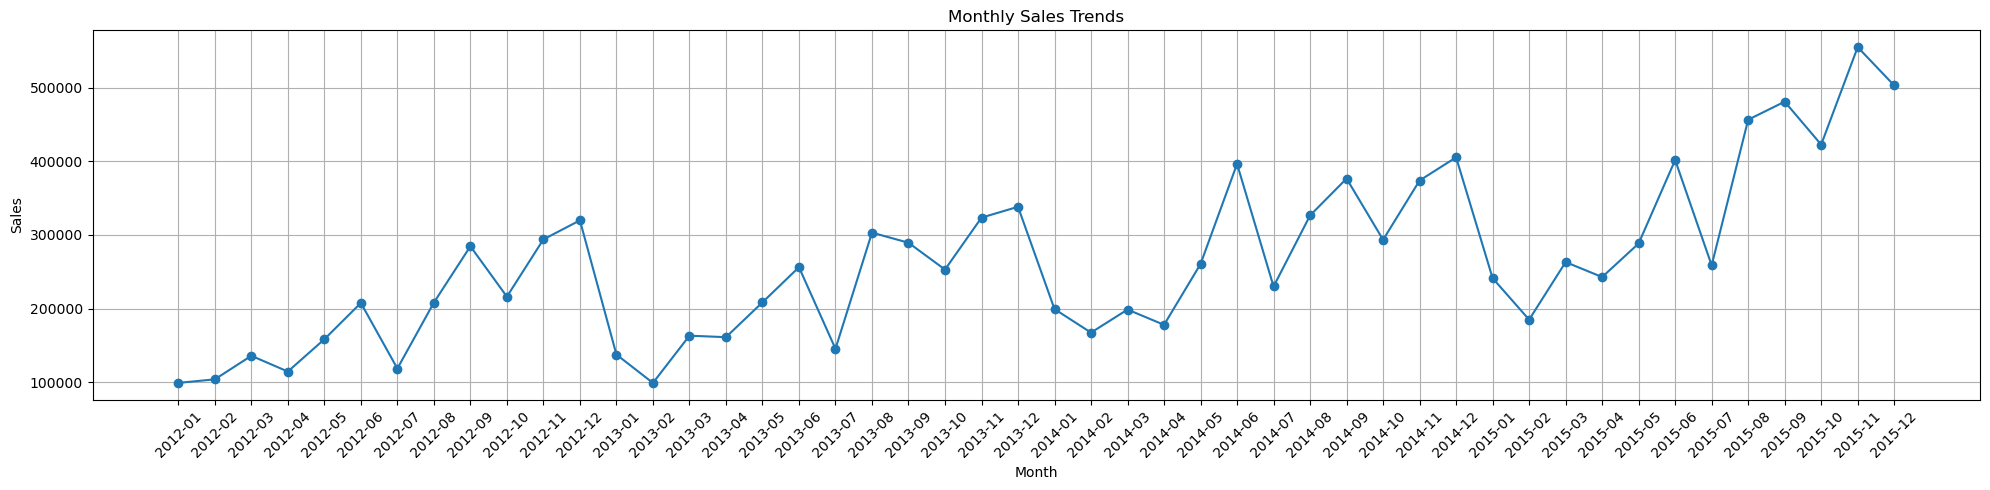

In [11]:
plt.figure(figsize=(20,5))
plt.plot(
    sales_month["month"],
    sales_month["total_sales"],
    marker="o"
)
plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Visualization_2_Sales_By_Category

In [12]:
query= """
select
    p.category,
    SUM(o.sales) AS total_sales
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.category;
"""
category_sales = pd.read_sql(query, conn)
category_sales

,category,total_sales
0,Furniture,4.110452e+06
1,Office Supplies,3.787493e+06
2,Technology,4.744557e+06


Plot_

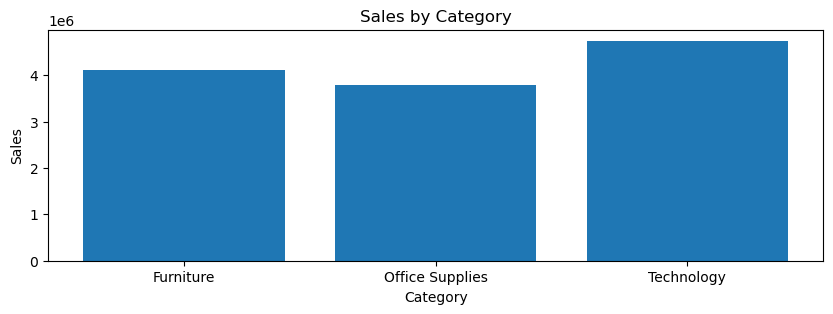

In [18]:
plt.figure(figsize=(10,3))
plt.bar(
    category_sales["category"],
    category_sales["total_sales"]
)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Visualization_3_Profit_by_Region

In [33]:
query = """
SELECT
    l.region,
    SUM(o.profit) AS total_profit
FROM orders AS o
JOIN locations AS l
ON o.location_id = l.location_id
GROUP BY l.region
ORDER BY total_profit DESC;
"""
profit_region = pd.read_sql(query, conn)
profit_region

,region,total_profit
0,Western Europe,218433.50850
1,Eastern Asia,167101.85100
2,Southern Asia,159336.42700
3,Central America,158981.64816
4,Oceania,120089.11200
5,Western US,108418.44890
6,Eastern US,91522.78000
7,Northern Europe,83923.91700
8,Eastern Europe,77084.88000
9,Southern Europe,70109.41800


Plot_

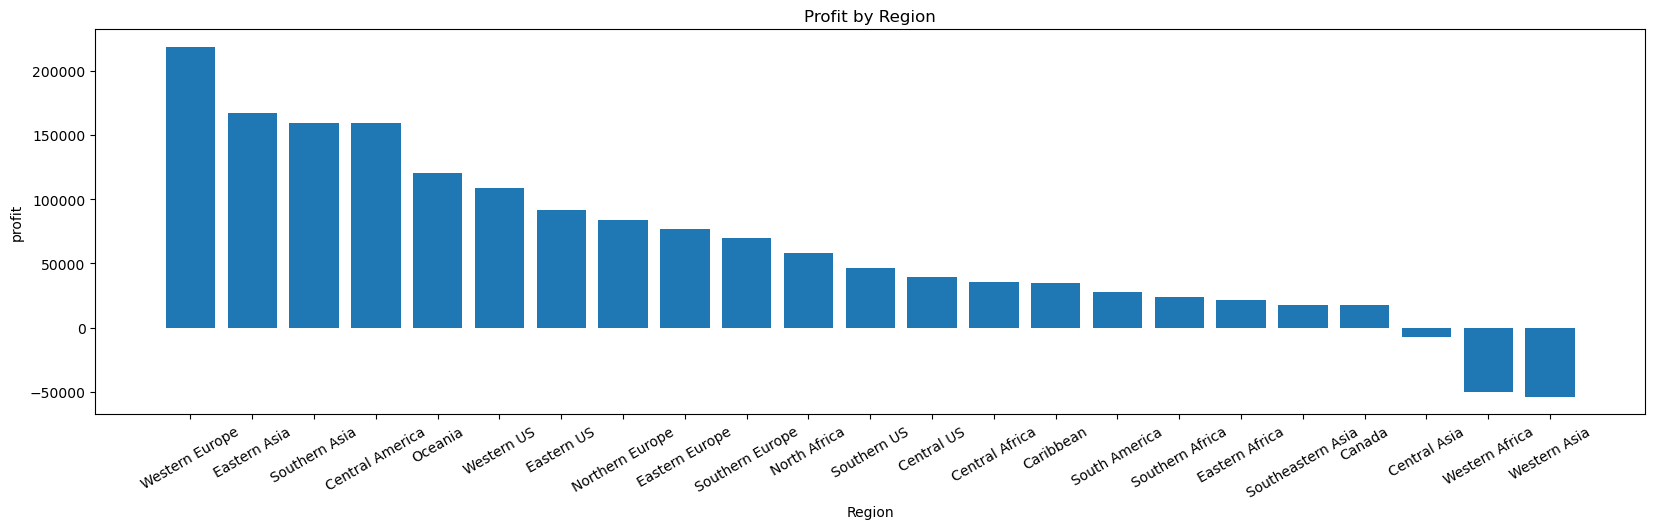

In [32]:
plt.figure(figsize=(20,5))
plt.bar(
    profit_region["region"],
    profit_region["total_profit"]
)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("profit")
plt.xticks(rotation=30)
plt.show()

Visualization_4_Top 10_Customers_by_Sales

In [46]:
query="""
select
    c.customer_name,
    SUM(o.sales) AS total_sales
FROM orders AS o
JOIN customers AS c
ON o.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""

top_customers= pd.read_sql(query, conn)
top_customers

,customer_name,total_sales
0,Tom Ashbrook,40488.07080
1,Tamara Chand,37457.33300
2,Greg Tran,35550.95428
3,Christopher Conant,35187.07640
4,Sean Miller,35170.93296
5,Bart Watters,32310.44650
6,Natalie Fritzler,31781.25850
7,Fred Hopkins,30400.67452
8,Jane Waco,30288.45030
9,Hunter Lopez,30243.56658


Plot_

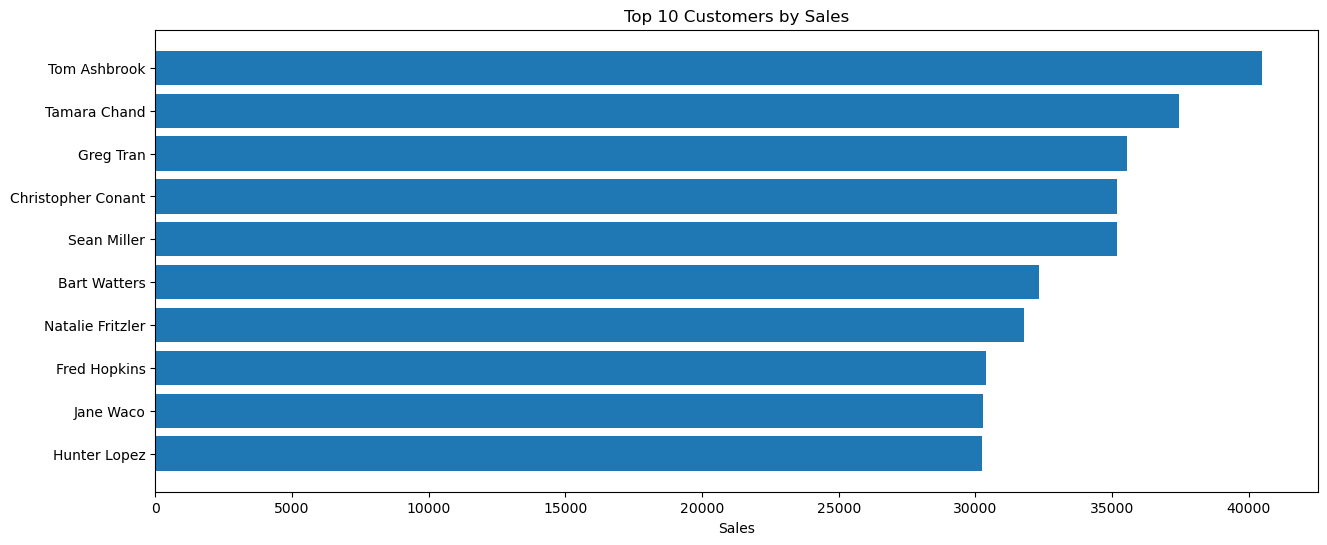

In [48]:
plt.figure(figsize=(15,6))
plt.barh(
    top_customers["customer_name"],
    top_customers["total_sales"]
)
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.show()

Visualization_5_Returned vs Non-Returned_Orders

In [49]:
query = """
SELECT
    r.returned,
    COUNT(o.order_id) AS total_orders
FROM orders o
LEFT JOIN returns r
ON o.order_id = r.order_id
GROUP BY r.returned;
"""
returns_summary = pd.read_sql(query, conn)
returns_summary

,returned,total_orders
0,None,49070
1,Yes,2220


Plot_

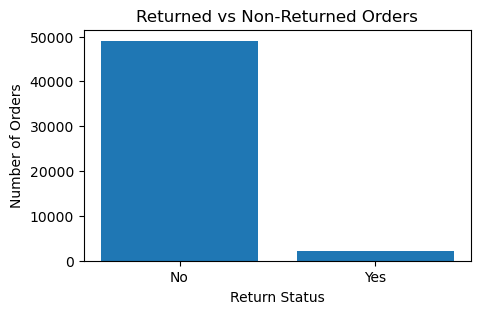

In [54]:
plt.figure(figsize=(5,3))
plt.bar(
    returns_summary["returned"].fillna("No"),
    returns_summary["total_orders"]
)
plt.title("Returned vs Non-Returned Orders")
plt.xlabel("Return Status")
plt.ylabel("Number of Orders")
plt.show()

Visualization_6_Shipping_Mode_Distribution

In [57]:
query="""
select
    ship_mode,
    COUNT(*) AS total_orders
FROM orders
GROUP BY ship_mode;
"""
ship_mode =pd.read_sql(query, conn)
ship_mode

,ship_mode,total_orders
0,First Class,7505
1,Same Day,2701
2,Second Class,10309
3,Standard Class,30775


Plot_

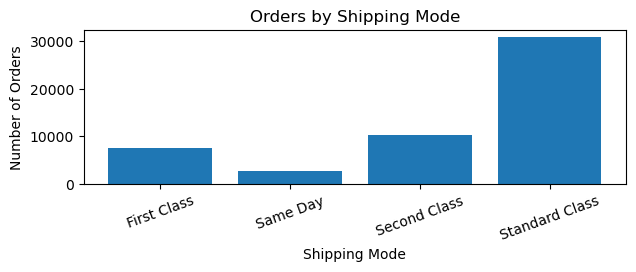

In [62]:
plt.figure(figsize=(7,2))
plt.bar(
    ship_mode["ship_mode"],
    ship_mode["total_orders"]
)
plt.title("Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

                                                    Geographic Sales Map

In [66]:
!pip install pycountry

In [67]:
import pycountry

def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

country_sales["iso3"] = country_sales["country"].apply(get_iso3)

country_sales.head()

,country,total_sales,iso3
0,Afghanistan,21673.32000,AFG
1,Albania,3888.12000,ALB
2,Algeria,36091.59000,DZA
3,Angola,25554.00000,AGO
4,Argentina,57511.78328,ARG


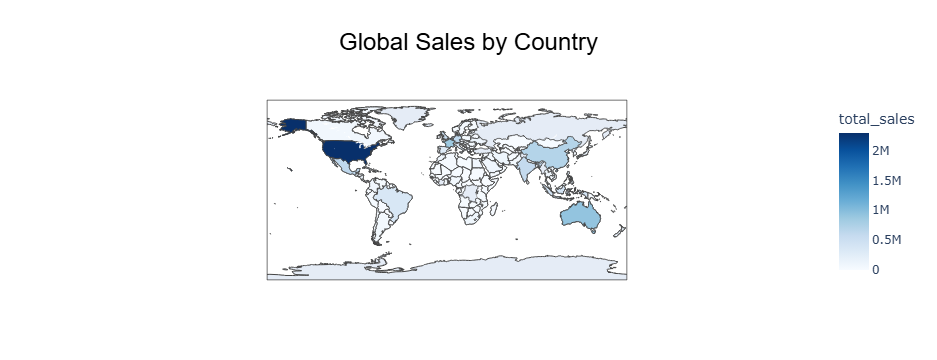

In [69]:
import plotly.express as px

fig = px.choropleth(
    country_sales,
    locations="iso3",
    locationmode="ISO-3",
    color="total_sales",
    hover_name="country",
    color_continuous_scale="Blues",
    title="Global Sales by Country"
)
fig.update_layout(
    title={
        "text": "Global Sales by Country",
        "x": 0.5,          # Center the title
        "xanchor": "center",
        "font": {
            "size": 24,
            "family": "Arial",
            "color": "black"
        }
    }
)
fig.show()

In [1]:
import os

print(os.getcwd())

C:\Users\debsu


In [2]:
import os
print(os.getcwd())

C:\Users\debsu
